In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch torchvision torchaudio --quiet
!pip install roboflow tqdm scikit-learn matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 112.5 MB/s eta 0:00:00


In [3]:
import os

DRIVE_ROOT = "/content/drive/MyDrive"
PROJECT_PATH = f"{DRIVE_ROOT}/Colab Notebooks/computer vision/Ultralytics YOLO/object classification"

os.makedirs(PROJECT_PATH, exist_ok=True)

print("Project will be saved to:", PROJECT_PATH)

Project will be saved to: /content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/object classification


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="VCLkIHPyGp4Yk2L3u2Ef")
project = rf.workspace("tenifayo").project("emotion-recognition-vweyv")
version = project.version(1)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Emotion-Recognition-1 in folder:: 100%|██████████| 23730/23730 [00:03<00:00, 6452.91it/s]


In [5]:
!cp -r "{dataset.location}" "{PROJECT_PATH}"
DATASET_PATH = f"{PROJECT_PATH}/{dataset.location.split('/')[-1]}"
print(DATASET_PATH)

/content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/object classification/Emotion-Recognition-1


In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(f"{DATASET_PATH}/train", transform=transform)
val_dataset = datasets.ImageFolder(f"{DATASET_PATH}/valid", transform=transform)
test_dataset = datasets.ImageFolder(f"{DATASET_PATH}/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [7]:
import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ViT
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Replace classification head
num_classes = len(train_dataset.classes)
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

model = model.to(device)

print("ViT loaded successfully")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 109MB/s]


ViT loaded successfully


In [8]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

In [9]:
import time
from tqdm import tqdm
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.heads.parameters(), lr=1e-3)

num_epochs = 10

train_losses = []
val_accuracies = []

torch.cuda.reset_peak_memory_stats()
start_training_time = time.time()

In [10]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    epoch_start = time.time()

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_time = time.time() - epoch_start

    # Validation
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

    val_acc = accuracy_score(targets, preds)

    train_losses.append(running_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Loss: {running_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Epoch Time: {epoch_time:.2f} sec")
    print(f"GPU Memory Used: {torch.cuda.max_memory_allocated()/1024**2:.2f} MB")

100%|██████████| 648/648 [09:23<00:00,  1.15it/s]



Epoch 1
Loss: 1021.5619
Val Accuracy: 0.4369
Epoch Time: 563.74 sec
GPU Memory Used: 603.92 MB


100%|██████████| 648/648 [09:10<00:00,  1.18it/s]



Epoch 2
Loss: 937.5345
Val Accuracy: 0.4773
Epoch Time: 550.83 sec
GPU Memory Used: 603.92 MB


100%|██████████| 648/648 [08:55<00:00,  1.21it/s]


...


Epoch 8
Loss: 855.4686
Val Accuracy: 0.4556
Epoch Time: 528.94 sec
GPU Memory Used: 603.92 MB


100%|██████████| 648/648 [08:45<00:00,  1.23it/s]



Epoch 9
Loss: 849.2015
Val Accuracy: 0.4833
Epoch Time: 525.22 sec
GPU Memory Used: 603.92 MB


100%|██████████| 648/648 [08:43<00:00,  1.24it/s]



Epoch 10
Loss: 845.0147
Val Accuracy: 0.4732
Epoch Time: 523.14 sec
GPU Memory Used: 603.92 MB


In [11]:
total_training_time = time.time() - start_training_time
print("Total Training Time:", total_training_time)

Total Training Time: 5755.345000743866


              precision    recall  f1-score   support

           0       0.35      0.30      0.32       143
           1       0.33      0.21      0.26        14
           2       0.32      0.20      0.25       142
           3       0.54      0.79      0.64       226
           4       0.44      0.52      0.48       166
           5       0.45      0.32      0.38       189
           6       0.69      0.64      0.66       116

    accuracy                           0.48       996
   macro avg       0.45      0.43      0.43       996
weighted avg       0.46      0.48      0.46       996



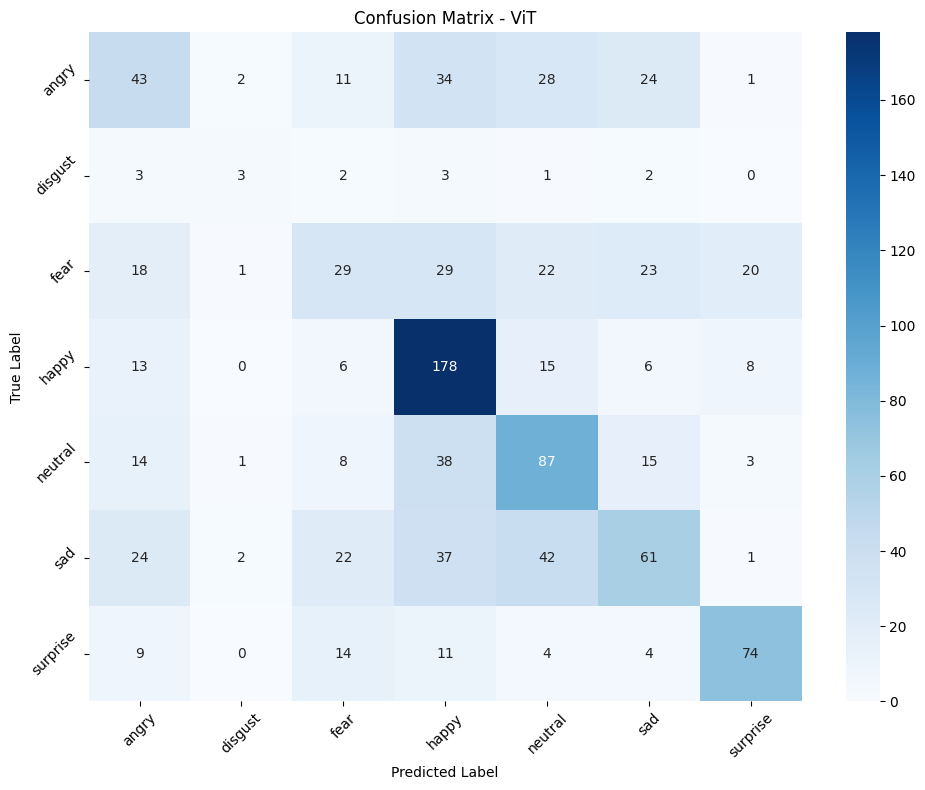

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
preds, targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        preds.extend(predicted.cpu().numpy())
        targets.extend(labels.numpy())

print(classification_report(targets, preds))

cm = confusion_matrix(targets, preds)

class_names = train_dataset.classes

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ViT")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{PROJECT_PATH}/confusion_matrix_vit.png")
plt.show()

In [13]:
model.eval()
start = time.time()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)

inference_time = time.time() - start
print("Inference Time:", inference_time)

Inference Time: 13.35705041885376


In [14]:
import json

torch.save(model.state_dict(), f"{PROJECT_PATH}/vit_model.pth")

results = {
    "training_time": total_training_time,
    "inference_time": inference_time,
    "val_accuracies": val_accuracies,
    "train_losses": train_losses,
    "gpu_memory_MB": torch.cuda.max_memory_allocated()/1024**2
}

with open(f"{PROJECT_PATH}/vit_results.json", "w") as f:
    json.dump(results, f)

print("ViT experiment saved successfully.")

ViT experiment saved successfully.


In [15]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("ViT Parameters:", count_params(model))

ViT Parameters: 85804039


Predicted Emotion: sad
Confidence: 33.84 %


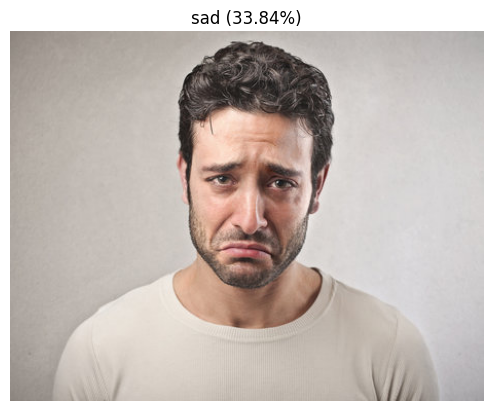

In [25]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Ensure model is in eval mode
model.eval()

# Define same transform used during training
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

image_path = f"{PROJECT_PATH}/sad1.jpg"

# Load image
image = Image.open(image_path).convert("RGB")

# Keep copy for display
display_image = image

# Transform
input_tensor = transform(image).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence, predicted_class = torch.max(probabilities, 0)

predicted_label = train_dataset.classes[predicted_class.item()]

print("Predicted Emotion:", predicted_label)
print("Confidence:", round(confidence.item()*100, 2), "%")

# Display image with prediction
plt.imshow(display_image)
plt.title(f"{predicted_label} ({confidence.item()*100:.2f}%)")
plt.axis("off")
plt.show()